In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load all CSV files
csv_files = [
    'Anime Odd One Out Test - Version 1.csv',
    'Anime Odd One Out Test - Version 3.csv', 
    'Anime Odd One Out Test - Version 4.csv'
]

# Combine all responses
all_responses = []
for filename in csv_files:
    filename = "../data/form_results/" + filename 
    df = pd.read_csv(filename)
    df['Version'] = filename.split('Version ')[1].split('.')[0]
    all_responses.append(df)

combined_df = pd.concat(all_responses, ignore_index=True)

print("=== BASIC DATA INFO ===")
print(f"Total responses: {len(combined_df)}")
print(f"Questions per response: 26")
print(f"Response distribution: {combined_df['Version'].value_counts().to_dict()}")

=== BASIC DATA INFO ===
Total responses: 29
Questions per response: 26
Response distribution: {'4': 13, '1': 9, '3': 7}


In [4]:
# Extract question answers - different correct answers per version
correct_answers_v1 = {
    'Q1. Which anime is the odd one out?': 'Junjo Romantica 2',
    'Q2. Which anime is the odd one out?': 'Bakuman.',
    'Q3. Which anime is the odd one out?': 'SHIMONETA:A Boring World Where the Concept of Dirty Jokes Doesn\'t Exist',
    'Q4. Which anime is the odd one out?': 'A Silent Voice',
    'Q5. Which anime is the odd one out?': 'Romeo x Juliet',
    'Q6. Which anime is the odd one out?': 'Dagashi Kashi',
    'Q7. Which anime is the odd one out?': 'Fate/kaleid liner Prisma Illya 3rei',
    'Q8. Which anime is the odd one out?': 'Initial D Fourth Stage',
    'Q9. Which anime is the odd one out?': 'Kamisama Kiss OVA',
    'Q10. Which anime is the odd one out?': 'The Fruit of Grisaia',
    'Q11. Which anime is the odd one out?': 'Buso Renkin',
    'Q12. Which anime is the odd one out?': 'Dragon Ball Z:The Return of Cooler',
    'Q13. Which anime is the odd one out?': 'My Hero Academia: Training of the Dead',
    'Q14. Which anime is the odd one out?': 'Zombie Land Saga',
    'Q15. Which anime is the odd one out?': 'Love, Chunibyo & Other Delusions!:Heart Throb Lite Shorts',
    'Q16. Which anime is the odd one out?': 'The Vision of Escaflowne',
    'Q17. Which anime is the odd one out?': 'Trigun - Badlands Rumble',
    'Q18. Which anime is the odd one out?': 'The Heroic Legend of Arslan:Dust Storm Dance',
    'Q19. Which anime is the odd one out?': 'Pokemon:Destiny Deoxys',
    'Q20. Which anime is the odd one out?': 'GARO:THE ANIMATION',
    'Q21. Which anime is the odd one out?': 'Sword Art Online',
    'Q22. Which anime is the odd one out?': 'A-Channel',
    'Q23. Which anime is the odd one out?': 'Broken Blade 3',
    'Q24. Which anime is the odd one out?': 'the Garden of sinners Chapter 8:The Final Chapter',
    'Q25. Which anime is the odd one out?': 'Cells at Work!!',
    'Q26. Which anime is the odd one out?': 'Remake our Life!'
}

correct_answers_v4 = {
    'Q1. Which anime is the odd one out?': 'Fairy Gone',
    'Q2. Which anime is the odd one out?': 'Akikan!',
    'Q3. Which anime is the odd one out?': 'That Time I Got Reincarnated as a Slime Season 2',
    'Q4. Which anime is the odd one out?': 'Hakuoki ~Demon of the Fleeting Blossom~ Record of the Jade Blood',
    'Q5. Which anime is the odd one out?': 'Food Wars! The Third Plate:Totsuki Train Arc',
    'Q6. Which anime is the odd one out?': 'Trinity Seven:Eternity Library & Alchemic Girl',
    'Q7. Which anime is the odd one out?': 'Dragon Ball Z Kai',
    'Q8. Which anime is the odd one out?': 'Waiting in the Summer',
    'Q9. Which anime is the odd one out?': 'Hell Girl:Three Vessels',
    'Q10. Which anime is the odd one out?': 'Strike Witches 2',
    'Q11. Which anime is the odd one out?': 'The Hidden Dungeon Only I Can Enter',
    'Q12. Which anime is the odd one out?': 'My Little Monster',
    'Q13. Which anime is the odd one out?': 'The Lost Village',
    'Q14. Which anime is the odd one out?': 'Bakugan:New Vestroia',
    'Q15. Which anime is the odd one out?': 'Beyond the Boundary:I\'ll Be Here - Past',
    'Q16. Which anime is the odd one out?': 'Flying Witch',
    'Q17. Which anime is the odd one out?': 'Trigun - Badlands Rumble',
    'Q18. Which anime is the odd one out?': 'Romeo x Juliet',
    'Q19. Which anime is the odd one out?': 'Code Geass:Akito the Exiled - The Wyvern Divided',
    'Q20. Which anime is the odd one out?': 'A Silent Voice',
    'Q21. Which anime is the odd one out?': 'The Stranger by the Shore',
    'Q22. Which anime is the odd one out?': 'Barakamon',
    'Q23. Which anime is the odd one out?': 'Detroit Metal City:The Animated Series',
    'Q24. Which anime is the odd one out?': 'Bakuman.',
    'Q25. Which anime is the odd one out?': 'Naruto the Movie 3:Guardians of the Crescent Moon Kingdom',
    'Q26. Which anime is the odd one out?': 'The Heroic Legend of Arslan:Dust Storm Dance'
}

# Version 4 corresponds to "Version 2" in the JSON
correct_answers_v3 = {
    'Q1. Which anime is the odd one out?': 'Code Geass:Akito the Exiled - The Wyvern Divided',
    'Q2. Which anime is the odd one out?': 'Full Metal Panic!',
    'Q3. Which anime is the odd one out?': 'Dragon Ball Z',
    'Q4. Which anime is the odd one out?': 'Amnesia',
    'Q5. Which anime is the odd one out?': 'Isekai Quartet 2',
    'Q6. Which anime is the odd one out?': 'The Vision of Escaflowne',
    'Q7. Which anime is the odd one out?': 'Bakuman.',
    'Q8. Which anime is the odd one out?': 'Magi:The Labyrinth of Magic',
    'Q9. Which anime is the odd one out?': 'Pokemon:Destiny Deoxys',
    'Q10. Which anime is the odd one out?': 'Tokyo Godfathers',
    'Q11. Which anime is the odd one out?': 'The Fruit of Grisaia',
    'Q12. Which anime is the odd one out?': 'Noragami Aragoto OVA',
    'Q13. Which anime is the odd one out?': 'Flying Witch',
    'Q14. Which anime is the odd one out?': 'Izetta:The Last Witch',
    'Q15. Which anime is the odd one out?': 'Junjo Romantica 2',
    'Q16. Which anime is the odd one out?': 'A-Channel',
    'Q17. Which anime is the odd one out?': 'High School DxD BorN Specials',
    'Q18. Which anime is the odd one out?': 'My Next Life as a Villainess:All Routes Lead to Doom!',
    'Q19. Which anime is the odd one out?': 'Aggretsuko',
    'Q20. Which anime is the odd one out?': 'Dragon Ball Z:The Return of Cooler',
    'Q21. Which anime is the odd one out?': 'Barakamon',
    'Q22. Which anime is the odd one out?': 'Canaan',
    'Q23. Which anime is the odd one out?': 'My Little Monster',
    'Q24. Which anime is the odd one out?': 'Trinity Seven:Eternity Library & Alchemic Girl',
    'Q25. Which anime is the odd one out?': 'Durarara!! x2 Ketsu',
    'Q26. Which anime is the odd one out?': 'Danganronpa 3:The End of Hope\'s Peak High School - Despair Arc'
}

# Map versions to their correct answers
version_answers = {
    '1': correct_answers_v1,
    '3': correct_answers_v3,
    '4': correct_answers_v4
}

In [5]:
# Calculate accuracy for each question using version-specific correct answers
question_cols = [col for col in combined_df.columns if col.startswith('Q') and not col.endswith('[Score]') and not col.endswith('[Feedback]')]
accuracy_results = []

for _, row in combined_df.iterrows():
    version = row['Version']
    correct_answers = version_answers[version]
    
    for q_col in question_cols:
        if q_col in correct_answers:
            correct_answer = correct_answers[q_col]
            user_answer = row[q_col]
            
            if pd.notna(user_answer):
                is_correct = user_answer == correct_answer
                
                accuracy_results.append({
                    'Question': q_col.split('.')[0],  # Q1, Q2, etc.
                    'Version': version,
                    'User_Answer': user_answer,
                    'Correct_Answer': correct_answer,
                    'Is_Correct': is_correct,
                    'Question_Number': int(q_col.split('.')[0][1:])  # Extract number for sorting
                })

accuracy_df = pd.DataFrame(accuracy_results)

# Calculate summary statistics per question
question_summary = accuracy_df.groupby(['Question', 'Question_Number']).agg({
    'Is_Correct': ['sum', 'count', 'mean']
}).round(3)

question_summary.columns = ['Correct_Count', 'Total_Count', 'Accuracy']
question_summary = question_summary.reset_index().sort_values('Question_Number')

print("\n=== OVERALL RESULTS ===")
overall_correct = question_summary['Correct_Count'].sum()
overall_total = question_summary['Total_Count'].sum()
overall_accuracy = overall_correct / overall_total

print(f"Overall Accuracy: {overall_accuracy:.1%} ({overall_correct}/{overall_total})")
print(f"Average per question: {question_summary['Accuracy'].mean():.1%}")
print(f"Standard deviation: {question_summary['Accuracy'].std():.1%}")

# Results by version
print(f"\n=== RESULTS BY VERSION ===")
version_results = accuracy_df.groupby('Version').agg({
    'Is_Correct': ['sum', 'count', 'mean']
}).round(3)
version_results.columns = ['Correct_Count', 'Total_Count', 'Accuracy']
print(version_results)


=== OVERALL RESULTS ===
Overall Accuracy: 43.1% (325/754)
Average per question: 43.1%
Standard deviation: 16.8%

=== RESULTS BY VERSION ===
         Correct_Count  Total_Count  Accuracy
Version                                      
1                   79          234     0.338
3                   77          182     0.423
4                  169          338     0.500


In [6]:
# Statistical significance test against random chance (20% for 5-choice questions)
random_chance = 0.20
print(f"\n=== STATISTICAL SIGNIFICANCE TEST ===")
print(f"Testing against random chance: {random_chance:.1%}")

# Binomial test for overall results
p_value_overall = stats.binom_test(overall_correct, overall_total, random_chance, alternative='greater')
print(f"Overall p-value: {p_value_overall:.6f}")
print(f"Statistically significant (p < 0.05): {'Yes' if p_value_overall < 0.05 else 'No'}")

# Effect size (Cohen's h)
observed_prop = overall_accuracy
expected_prop = random_chance
cohens_h = 2 * (np.arcsin(np.sqrt(observed_prop)) - np.arcsin(np.sqrt(expected_prop)))
print(f"Effect size (Cohen's h): {cohens_h:.3f}")

# Interpret effect size
if abs(cohens_h) < 0.2:
    effect_interpretation = "Small"
elif abs(cohens_h) < 0.5:
    effect_interpretation = "Medium"  
else:
    effect_interpretation = "Large"
print(f"Effect interpretation: {effect_interpretation}")

# Statistical test by version
print(f"\n=== VERSION SIGNIFICANCE TESTS ===")
for version in version_results.index:
    version_correct = version_results.loc[version, 'Correct_Count']
    version_total = version_results.loc[version, 'Total_Count']
    version_p_value = stats.binom_test(version_correct, version_total, random_chance, alternative='greater')
    significance = "Yes" if version_p_value < 0.05 else "No"
    accuracy = version_results.loc[version, 'Accuracy']
    print(f"Version {version}: {accuracy:.1%} accuracy, p={version_p_value:.4f}, significant: {significance}")

print(f"\n=== QUESTION-BY-QUESTION RESULTS ===")
print(question_summary[['Question', 'Accuracy', 'Correct_Count', 'Total_Count']].to_string(index=False))

# Find best and worst performing questions
best_questions = question_summary.nlargest(5, 'Accuracy')[['Question', 'Accuracy']]
worst_questions = question_summary.nsmallest(5, 'Accuracy')[['Question', 'Accuracy']]

print(f"\n=== BEST PERFORMING QUESTIONS ===")
print(best_questions.to_string(index=False))

print(f"\n=== WORST PERFORMING QUESTIONS ===")
print(worst_questions.to_string(index=False))


=== STATISTICAL SIGNIFICANCE TEST ===
Testing against random chance: 20.0%
Overall p-value: 0.000000
Statistically significant (p < 0.05): Yes
Effect size (Cohen's h): 0.505
Effect interpretation: Large

=== VERSION SIGNIFICANCE TESTS ===
Version 1: 33.8% accuracy, p=0.0000, significant: Yes
Version 3: 42.3% accuracy, p=0.0000, significant: Yes
Version 4: 50.0% accuracy, p=0.0000, significant: Yes

=== QUESTION-BY-QUESTION RESULTS ===
Question  Accuracy  Correct_Count  Total_Count
      Q1     0.655             19           29
      Q2     0.379             11           29
      Q3     0.517             15           29
      Q4     0.207              6           29
      Q5     0.345             10           29
      Q6     0.103              3           29
      Q7     0.276              8           29
      Q8     0.379             11           29
      Q9     0.345             10           29
     Q10     0.310              9           29
     Q11     0.414             12          

C:\Users\osher\AppData\Local\Temp\ipykernel_16708\3176833354.py:7: DeprecationWarning: 'binom_test' is deprecated in favour of 'binomtest' from version 1.7.0 and will be removed in Scipy 1.12.0.
  p_value_overall = stats.binom_test(overall_correct, overall_total, random_chance, alternative='greater')
C:\Users\osher\AppData\Local\Temp\ipykernel_16708\3176833354.py:31: DeprecationWarning: 'binom_test' is deprecated in favour of 'binomtest' from version 1.7.0 and will be removed in Scipy 1.12.0.
  version_p_value = stats.binom_test(version_correct, version_total, random_chance, alternative='greater')



=== CLUSTER-BY-CLUSTER ANALYSIS ===
Each cluster has 2 questions testing the same anime grouping

CLUSTER PERFORMANCE SUMMARY:
 Cluster Questions  Accuracy  Correct  Total Significant
       1     Q1-Q2     0.517       30     58         Yes
       2     Q3-Q4     0.362       21     58         Yes
       3     Q5-Q6     0.224       13     58          No
       4     Q7-Q8     0.328       19     58         Yes
       5    Q9-Q10     0.328       19     58         Yes
       6   Q11-Q12     0.466       27     58         Yes
       7   Q13-Q14     0.414       24     58         Yes
       8   Q15-Q16     0.345       20     58         Yes
       9   Q17-Q18     0.793       46     58         Yes
      10   Q19-Q20     0.414       24     58         Yes
      11   Q21-Q22     0.448       26     58         Yes
      12   Q23-Q24     0.414       24     58         Yes
      13   Q25-Q26     0.552       32     58         Yes

=== CLUSTER SIGNIFICANCE DETAILS ===
Cluster 1 (Q1-Q2): 51.7% accuracy, p

C:\Users\osher\AppData\Local\Temp\ipykernel_16708\3462952700.py:25: DeprecationWarning: 'binom_test' is deprecated in favour of 'binomtest' from version 1.7.0 and will be removed in Scipy 1.12.0.
  p_value = stats.binom_test(cluster_correct, cluster_total, random_chance, alternative='greater')


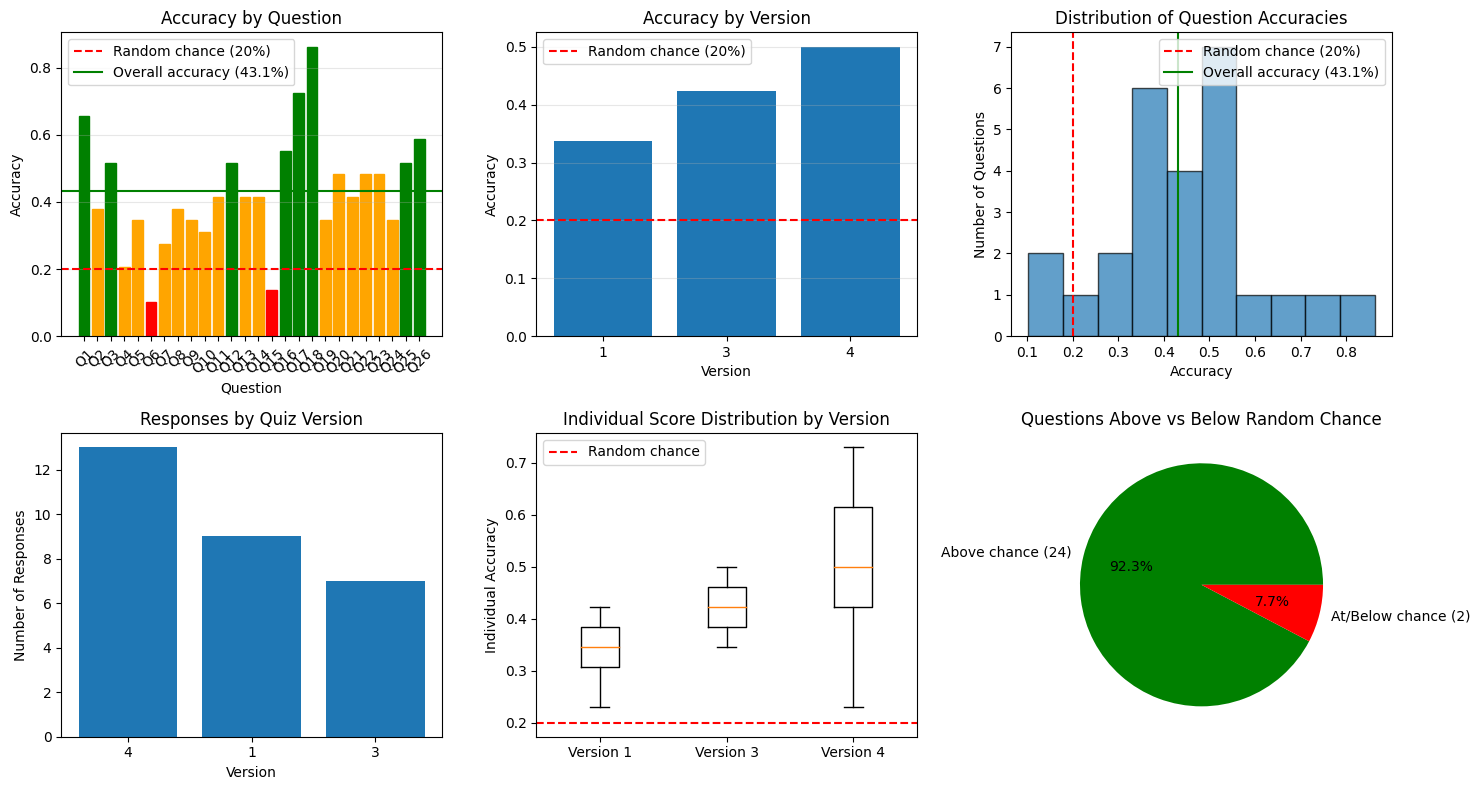


=== SUMMARY ===
• 29 people took the quiz across 3 versions
• Overall accuracy: 43.1% (significantly above 20% chance: Yes)
• Best question: Q18 (86.2%)
• Worst question: Q6 (10.3%)
• 24 out of 26 questions performed above random chance
• Effect size: Large (Cohen's h = 0.505)
• Version performance: V1=33.8%, V3=42.3%, V4=50.0%


In [7]:
# Map questions to clusters (Q1-Q2 = Cluster 1, Q3-Q4 = Cluster 2, etc.)
def get_cluster_from_question(question_num):
    return ((question_num - 1) // 2) + 1

question_summary['Cluster'] = question_summary['Question_Number'].apply(get_cluster_from_question)
accuracy_df['Cluster'] = accuracy_df['Question_Number'].apply(get_cluster_from_question)

print(f"\n=== CLUSTER-BY-CLUSTER ANALYSIS ===")
print("Each cluster has 2 questions testing the same anime grouping")
print()

cluster_results = accuracy_df.groupby('Cluster').agg({
    'Is_Correct': ['sum', 'count', 'mean']
}).round(3)
cluster_results.columns = ['Correct_Count', 'Total_Count', 'Accuracy']

# Statistical significance test for each cluster
cluster_stats = []
for cluster in sorted(cluster_results.index):
    cluster_correct = cluster_results.loc[cluster, 'Correct_Count']
    cluster_total = cluster_results.loc[cluster, 'Total_Count']
    cluster_accuracy = cluster_results.loc[cluster, 'Accuracy']
    
    # Binomial test against random chance
    p_value = stats.binom_test(cluster_correct, cluster_total, random_chance, alternative='greater')
    significant = "Yes" if p_value < 0.05 else "No"
    
    # Get questions for this cluster
    cluster_questions = question_summary[question_summary['Cluster'] == cluster]['Question'].tolist()
    
    cluster_stats.append({
        'Cluster': cluster,
        'Questions': f"{cluster_questions[0]}-{cluster_questions[1]}",
        'Accuracy': cluster_accuracy,
        'Correct': cluster_correct,
        'Total': cluster_total,
        'P_Value': p_value,
        'Significant': significant
    })

cluster_stats_df = pd.DataFrame(cluster_stats)

print("CLUSTER PERFORMANCE SUMMARY:")
print(cluster_stats_df[['Cluster', 'Questions', 'Accuracy', 'Correct', 'Total', 'Significant']].to_string(index=False))

print(f"\n=== CLUSTER SIGNIFICANCE DETAILS ===")
for _, row in cluster_stats_df.iterrows():
    print(f"Cluster {row['Cluster']} ({row['Questions']}): {row['Accuracy']:.1%} accuracy, p={row['P_Value']:.4f}, significant: {row['Significant']}")

# Cluster performance rankings
print(f"\n=== BEST PERFORMING CLUSTERS ===")
best_clusters = cluster_stats_df.nlargest(5, 'Accuracy')[['Cluster', 'Questions', 'Accuracy', 'Significant']]
print(best_clusters.to_string(index=False))

print(f"\n=== WORST PERFORMING CLUSTERS ===")
worst_clusters = cluster_stats_df.nsmallest(5, 'Accuracy')[['Cluster', 'Questions', 'Accuracy', 'Significant']]
print(worst_clusters.to_string(index=False))

# Overall cluster statistics
significant_clusters = sum(cluster_stats_df['P_Value'] < 0.05)
above_chance_clusters = sum(cluster_stats_df['Accuracy'] > random_chance)

print(f"\n=== CLUSTER SUMMARY STATISTICS ===")
print(f"Clusters significantly above chance (p < 0.05): {significant_clusters}/13")
print(f"Clusters above 20% accuracy: {above_chance_clusters}/13")
print(f"Best cluster accuracy: {cluster_stats_df['Accuracy'].max():.1%}")
print(f"Worst cluster accuracy: {cluster_stats_df['Accuracy'].min():.1%}")
print(f"Average cluster accuracy: {cluster_stats_df['Accuracy'].mean():.1%}")
print(f"Cluster accuracy std dev: {cluster_stats_df['Accuracy'].std():.1%}")

# Question consistency within clusters
print(f"\n=== WITHIN-CLUSTER CONSISTENCY ===")
consistency_results = []
for cluster in sorted(cluster_results.index):
    cluster_questions = question_summary[question_summary['Cluster'] == cluster]
    if len(cluster_questions) == 2:
        q1_acc = cluster_questions.iloc[0]['Accuracy']
        q2_acc = cluster_questions.iloc[1]['Accuracy']
        consistency = abs(q1_acc - q2_acc)
        avg_acc = (q1_acc + q2_acc) / 2
        
        consistency_results.append({
            'Cluster': cluster,
            'Q1_Accuracy': q1_acc,
            'Q2_Accuracy': q2_acc,
            'Average': avg_acc,
            'Difference': consistency,
            'Consistent': "Yes" if consistency <= 0.2 else "No"
        })

consistency_df = pd.DataFrame(consistency_results)
print("Within-cluster question consistency (difference < 20% = consistent):")
print(consistency_df.to_string(index=False))

consistent_clusters = sum(consistency_df['Difference'] <= 0.2)
print(f"\nConsistent clusters (questions within 20% of each other): {consistent_clusters}/13")
plt.figure(figsize=(15, 8))

# Overall accuracy by question
plt.subplot(2, 3, 1)
bars = plt.bar(question_summary['Question'], question_summary['Accuracy'])
plt.axhline(y=random_chance, color='red', linestyle='--', label=f'Random chance ({random_chance:.0%})')
plt.axhline(y=overall_accuracy, color='green', linestyle='-', label=f'Overall accuracy ({overall_accuracy:.1%})')
plt.title('Accuracy by Question')
plt.xlabel('Question')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Color bars based on performance
for bar, acc in zip(bars, question_summary['Accuracy']):
    if acc >= 0.5:
        bar.set_color('green')
    elif acc >= random_chance:
        bar.set_color('orange')
    else:
        bar.set_color('red')

# Accuracy by version
plt.subplot(2, 3, 2)
bars2 = plt.bar(version_results.index, version_results['Accuracy'])
plt.axhline(y=random_chance, color='red', linestyle='--', label=f'Random chance ({random_chance:.0%})')
plt.title('Accuracy by Version')
plt.xlabel('Version')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Distribution of accuracies
plt.subplot(2, 3, 3)
plt.hist(question_summary['Accuracy'], bins=10, edgecolor='black', alpha=0.7)
plt.axvline(x=random_chance, color='red', linestyle='--', label=f'Random chance ({random_chance:.0%})')
plt.axvline(x=overall_accuracy, color='green', linestyle='-', label=f'Overall accuracy ({overall_accuracy:.1%})')
plt.title('Distribution of Question Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Number of Questions')
plt.legend()

# Response counts by version
plt.subplot(2, 3, 4)
version_counts = combined_df['Version'].value_counts()
plt.bar(version_counts.index, version_counts.values)
plt.title('Responses by Quiz Version')
plt.xlabel('Version')
plt.ylabel('Number of Responses')

# Individual response patterns
plt.subplot(2, 3, 5)
individual_scores = accuracy_df.groupby(['Version', accuracy_df.index // 26])['Is_Correct'].mean()
plt.boxplot([individual_scores[individual_scores.index.get_level_values(0) == v].values 
             for v in ['1', '3', '4']], labels=['Version 1', 'Version 3', 'Version 4'])
plt.axhline(y=random_chance, color='red', linestyle='--', label=f'Random chance')
plt.title('Individual Score Distribution by Version')
plt.ylabel('Individual Accuracy')
plt.legend()

# Questions above/below chance
plt.subplot(2, 3, 6)
above_chance = sum(question_summary['Accuracy'] > random_chance)
below_chance = sum(question_summary['Accuracy'] <= random_chance)
plt.pie([above_chance, below_chance], labels=[f'Above chance ({above_chance})', f'At/Below chance ({below_chance})'],
        autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Questions Above vs Below Random Chance')

plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY ===")
print(f"• {len(combined_df)} people took the quiz across 3 versions")
print(f"• Overall accuracy: {overall_accuracy:.1%} (significantly above {random_chance:.0%} chance: {'Yes' if p_value_overall < 0.05 else 'No'})")
print(f"• Best question: {best_questions.iloc[0]['Question']} ({best_questions.iloc[0]['Accuracy']:.1%})")
print(f"• Worst question: {worst_questions.iloc[0]['Question']} ({worst_questions.iloc[0]['Accuracy']:.1%})")
print(f"• {above_chance} out of 26 questions performed above random chance")
print(f"• Effect size: {effect_interpretation} (Cohen's h = {cohens_h:.3f})")
print(f"• Version performance: V1={version_results.loc['1', 'Accuracy']:.1%}, V3={version_results.loc['3', 'Accuracy']:.1%}, V4={version_results.loc['4', 'Accuracy']:.1%}")

In [8]:
cluster_stats_df

,Cluster,Questions,Accuracy,Correct,Total,P_Value,Significant
0,1,Q1-Q2,0.517,30,58,7.756358e-08,Yes
1,2,Q3-Q4,0.362,21,58,3.047364e-03,Yes
2,3,Q5-Q6,0.224,13,58,3.725389e-01,No
3,4,Q7-Q8,0.328,19,58,1.532256e-02,Yes
4,5,Q9-Q10,0.328,19,58,1.532256e-02,Yes
5,6,Q11-Q12,0.466,27,58,4.782730e-06,Yes
6,7,Q13-Q14,0.414,24,58,1.628401e-04,Yes
7,8,Q15-Q16,0.345,20,58,7.070325e-03,Yes
8,9,Q17-Q18,0.793,46,58,4.604331e-22,Yes
9,10,Q19-Q20,0.414,24,58,1.628401e-04,Yes


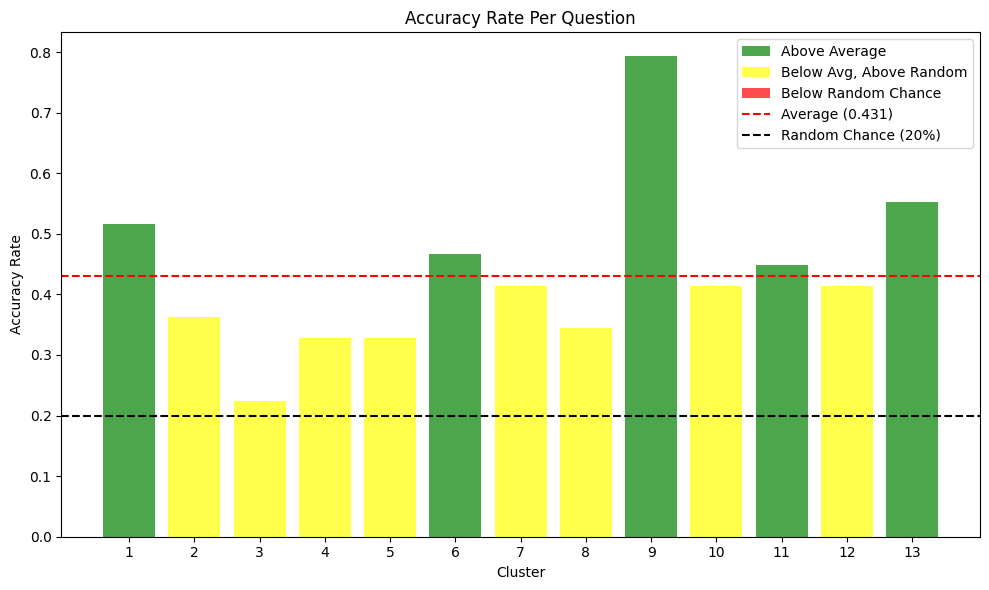

In [12]:
# Simple Accuracy Bar Plot
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming cluster_stats_df is already loaded
# If not, load your data here:
# cluster_stats_df = pd.read_csv('../data/your_file.csv')

# Calculate average accuracy
avg_accuracy = cluster_stats_df['Accuracy'].mean()

# Create color list based on conditions
colors = []
for acc in cluster_stats_df['Accuracy']:
    if acc >= avg_accuracy:
        colors.append('green')
    elif acc >= 0.20:
        colors.append('yellow')
    else:
        colors.append('red')

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_stats_df['Cluster'], cluster_stats_df['Accuracy'], 
               color=colors, alpha=0.7)

# Add horizontal lines
plt.axhline(y=avg_accuracy, color='red', linestyle='--', 
            label=f'Average Accuracy ({avg_accuracy:.3f})')
plt.axhline(y=0.20, color='black', linestyle='--', 
            label='Random Chance (20%)')

# Create custom legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Above Average'),
    Patch(facecolor='yellow', alpha=0.7, label='Below Avg, Above Random'),
    Patch(facecolor='red', alpha=0.7, label='Below Random Chance'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Average ({avg_accuracy:.3f})'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='Random Chance (20%)')
]

# Formatting
plt.xlabel('Cluster')
plt.ylabel('Accuracy Rate')
plt.title('Accuracy Rate Per Question')
plt.legend(handles=legend_elements, loc='upper right')
plt.xticks(cluster_stats_df['Cluster'])  # Show all cluster values
plt.tight_layout()
plt.show()